In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
111300,818860012482918321,2025-02-24,146.71.50.198,0,0,False,24,2,0
111565,818860012482918321,2025-02-25,146.71.50.198,0,1,False,25,2,0
111830,818860012482918321,2025-02-26,146.71.50.198,0,2,False,26,2,0
112095,818860012482918321,2025-02-27,146.71.50.198,0,3,False,27,2,0
112360,818860012482918321,2025-02-28,146.71.50.198,2,4,False,28,2,1
...,...,...,...,...,...,...,...,...,...
136475,818860012482918321,2025-05-30,146.71.50.198,0,4,False,30,5,0
136740,818860012482918321,2025-05-31,146.71.50.198,0,5,True,31,5,0
137005,818860012482918321,2025-06-01,146.71.50.198,0,6,True,1,6,0
137270,818860012482918321,2025-06-02,146.71.50.198,0,0,False,2,6,0


In [2]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_19412\1570248052.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


In [3]:
df[df['date'] == '2025-06-03']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
137696,818860012482918321,2025-06-03,102.129.153.158,0,1,False,3,6,0
137679,818860012482918321,2025-06-03,102.129.153.43,0,1,False,3,6,0
137547,818860012482918321,2025-06-03,102.129.153.71,0,1,False,3,6,0
137697,818860012482918321,2025-06-03,102.165.16.161,0,1,False,3,6,0
137764,818860012482918321,2025-06-03,103.147.185.248,0,1,False,3,6,0
...,...,...,...,...,...,...,...,...,...
137646,818860012482918321,2025-06-03,international.standardbank.com/,0,1,False,3,6,0
137724,818860012482918321,2025-06-03,pub.marq.com/,0,1,False,3,6,0
137674,818860012482918321,2025-06-03,realinvestmentadvice.com/,0,1,False,3,6,0
137660,818860012482918321,2025-06-03,www.emergencylighting.com/,0,1,False,3,6,0


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,13.0,0.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,...,1.412573e-02,1.485474e-01,0.052973,0.052973,0.549934,0.958381,0.000014,0.000014,0.999978,0.999984
1,102.129.153.43,0,18.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,...,4.584132e-03,5.061108e-02,0.040274,0.040274,0.393373,0.928929,0.000014,0.000014,0.000022,0.999984
2,102.129.153.71,0,5.0,1.0,2.0,18.800000,-0.223835,6.449301e-02,0.372911,0.606759,...,6.152537e-01,9.999795e-01,0.852953,0.852953,0.940681,0.991033,0.999971,0.999971,0.999978,0.999984
3,102.165.16.161,0,54.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,...,1.066071e-05,1.204987e-04,0.004991,0.004991,0.004416,0.127006,0.000014,0.000014,0.000022,0.000028
4,103.147.185.248,0,12.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,7.869941e-05,8.892331e-04,0.074973,0.074973,0.736953,0.937055,0.000014,0.000014,0.999978,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,international.standardbank.com/,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,...,3.674838e-14,4.151124e-13,0.000558,0.000558,0.000040,0.000356,0.000014,0.000014,0.000022,0.000028
261,pub.marq.com/,0,20.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,...,5.265324e-02,4.574189e-01,0.046916,0.046916,0.339394,0.875668,0.000014,0.000014,0.000022,0.999984
262,realinvestmentadvice.com/,0,1.0,2.0,3.0,7.833333,-0.001589,9.516258e-02,0.503415,0.753403,...,9.999964e-01,1.000000e+00,0.998019,0.998019,0.992782,0.996766,0.999971,0.999971,0.999978,0.999984
263,www.emergencylighting.com/,0,13.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,6.178926e-05,6.982244e-04,0.071217,0.071217,0.712291,0.929816,0.000014,0.000014,0.999978,0.999984


In [5]:
output.drop(columns=['indicator'])

,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,0,13.0,0.0,1.0,37.500000,-0.388889,3.278390e-02,0.208110,0.372911,0.632121,...,1.412573e-02,1.485474e-01,0.052973,0.052973,0.549934,0.958381,0.000014,0.000014,0.999978,0.999984
1,0,18.0,0.0,1.0,36.500000,-0.403846,3.278390e-02,0.208110,0.372911,0.632121,...,4.584132e-03,5.061108e-02,0.040274,0.040274,0.393373,0.928929,0.000014,0.000014,0.000022,0.999984
2,0,5.0,1.0,2.0,18.800000,-0.223835,6.449301e-02,0.372911,0.606759,0.864665,...,6.152537e-01,9.999795e-01,0.852953,0.852953,0.940681,0.991033,0.999971,0.999971,0.999978,0.999984
3,0,54.0,0.0,0.0,6.000000,-0.381966,9.999995e-07,0.000007,0.000014,0.000030,...,1.066071e-05,1.204987e-04,0.004991,0.004991,0.004416,0.127006,0.000014,0.000014,0.000022,0.000028
4,0,12.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,7.869941e-05,8.892331e-04,0.074973,0.074973,0.736953,0.937055,0.000014,0.000014,0.999978,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,0,100.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,3.674838e-14,4.151124e-13,0.000558,0.000558,0.000040,0.000356,0.000014,0.000014,0.000022,0.000028
261,0,20.0,0.0,1.0,9.600000,0.122880,3.278390e-02,0.208110,0.372911,0.632121,...,5.265324e-02,4.574189e-01,0.046916,0.046916,0.339394,0.875668,0.000014,0.000014,0.000022,0.999984
262,0,1.0,2.0,3.0,7.833333,-0.001589,9.516258e-02,0.503415,0.753403,0.950213,...,9.999964e-01,1.000000e+00,0.998019,0.998019,0.992782,0.996766,0.999971,0.999971,0.999978,0.999984
263,0,13.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,6.178926e-05,6.982244e-04,0.071217,0.071217,0.712291,0.929816,0.000014,0.000014,0.999978,0.999984


In [6]:
output[output['indicator'] == '102.129.153.158']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,13.0,0.0,1.0,37.5,-0.388889,0.032784,0.20811,0.372911,...,0.014126,0.148547,0.052973,0.052973,0.549934,0.958381,0.000014,0.000014,0.999978,0.999984


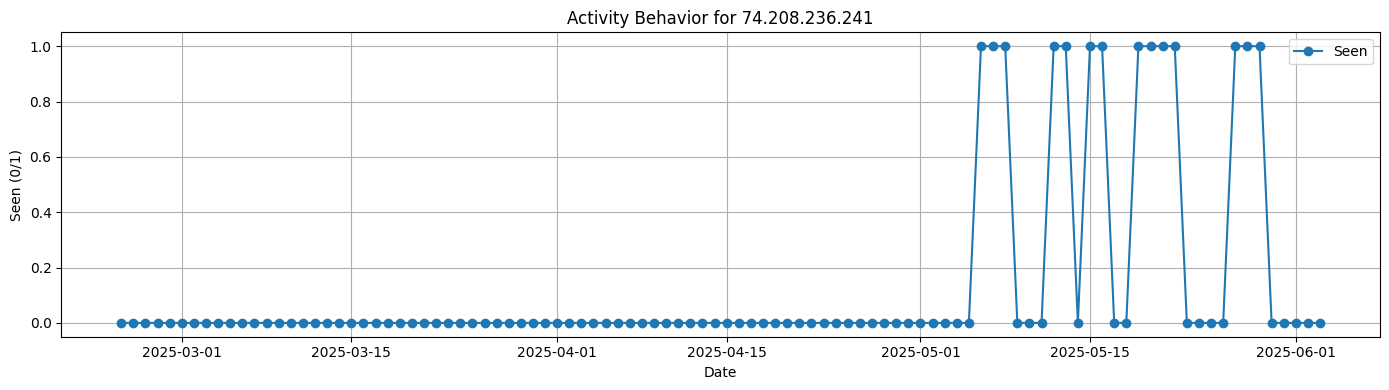

In [7]:
import matplotlib.pyplot as plt

indicator_id = '74.208.236.241'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [8]:
output[output['indicator'] == '113.96.236.11']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
21,113.96.236.11,0,75.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,...,1.003865e-07,0.000001,0.001577,0.001577,0.000322,0.012311,0.000014,0.000014,0.000022,0.000028


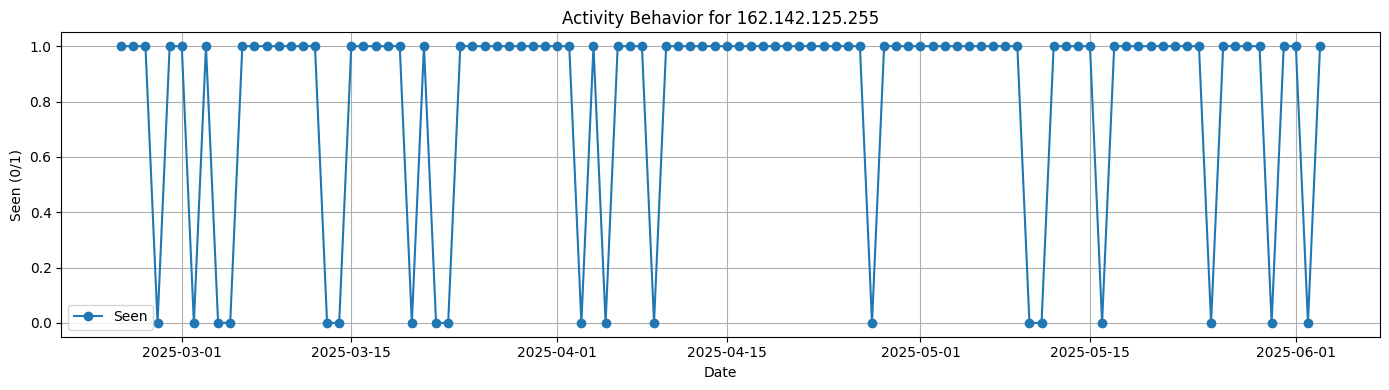

In [9]:
indicator_id = '162.142.125.255'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [10]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
134234,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
134102,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
134252,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
134319,818860012482918321,2025-05-21,103.147.185.248,0,2,False,21,5,0
134336,818860012482918321,2025-05-21,103.156.92.159,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
134311,818860012482918321,2025-05-21,93.123.109.231,0,2,False,21,5,0
134245,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
134201,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
134279,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
import numpy as np

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

# Compute confidence tags using raw probabilities (not formatted as strings)
output['confidence_today'] = output.apply(
    lambda row: classify_window(
        row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = np.clip(output[col].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = np.clip(output['prob_today'].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Final Output ---
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



C:\Users\jaskew\AppData\Local\Temp\ipykernel_19412\3344784157.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_19412\3344784157.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)


,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.129.153.158,0,0.0,1.0,0.31%,Today: Low confidence,7.87%,7-Day: Low confidence,53.04%,14-Day: Low confidence,76.43%,30-Day: Low confidence
1,102.129.153.43,0,0.0,1.0,0.24%,Today: Low confidence,7.46%,7-Day: Low confidence,23.1%,14-Day: Low confidence,48.1%,30-Day: Low confidence
2,102.129.153.71,0,1.0,2.0,1.08%,Today: Low confidence,64.27%,7-Day: Possibly active,86.8%,14-Day: Possibly active,100.0%,30-Day: Possibly active
3,102.165.16.161,0,0.0,0.0,0.02%,Today: Low confidence,0.15%,7-Day: Low confidence,0.13%,14-Day: Low confidence,3.81%,30-Day: Low confidence
4,103.147.185.248,0,0.0,1.0,4.96%,Today: Low confidence,8.49%,7-Day: Low confidence,58.3%,14-Day: Low confidence,72.1%,30-Day: Low confidence
...,...,...,...,...,...,...,...,...,...,...,...,...
260,international.standardbank.com/,0,0.0,0.0,0.21%,Today: Low confidence,0.02%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
261,pub.marq.com/,0,0.0,1.0,0.1%,Today: Low confidence,7.8%,7-Day: Low confidence,22.69%,14-Day: Low confidence,56.67%,30-Day: Low confidence
262,realinvestmentadvice.com/,0,2.0,3.0,4.57%,Today: Low confidence,88.76%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
263,www.emergencylighting.com/,0,0.0,1.0,4.79%,Today: Low confidence,8.38%,7-Day: Low confidence,57.56%,14-Day: Low confidence,71.88%,30-Day: Low confidence


### Observed Indicator Activity Analysis

In [12]:
production_analysis_indicators = production_output[production_output['Observed Today'] == 1]
production_analysis_indicators

,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
7,103.163.118.122,1,1.0,1.0,30.88%,Today: Possibly active,58.21%,7-Day: Possibly active,65.63%,14-Day: Possibly active,74.1%,30-Day: Possibly active
15,104.21.48.1,1,7.0,30.0,98.02%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
66,162.142.125.242,1,5.0,23.0,70.73%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
67,162.142.125.247,1,5.0,24.0,70.56%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
68,162.142.125.255,1,5.0,24.0,70.4%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
83,179.43.161.218,1,1.0,1.0,30.88%,Today: Possibly active,58.21%,7-Day: Possibly active,65.63%,14-Day: Possibly active,74.1%,30-Day: Possibly active
86,185.230.63.171,1,7.0,23.0,98.73%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
104,195.3.221.137,1,1.0,1.0,30.88%,Today: Possibly active,58.21%,7-Day: Possibly active,65.63%,14-Day: Possibly active,74.1%,30-Day: Possibly active
109,196.251.87.59,1,4.0,5.0,49.04%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
123,209.141.35.136,1,1.0,1.0,30.88%,Today: Possibly active,58.21%,7-Day: Possibly active,65.63%,14-Day: Possibly active,74.1%,30-Day: Possibly active


In [13]:
import os
import pandas as pd
from datetime import datetime, timedelta

# Base file path with placeholder for date
base_path = r"Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d{date}.csv"
#base_path = r"C:\Users\jaskew\Documents\project_repository\data\raw\ObservationDataFiles\htoc_opdiv_obs_d{date}.csv"
date_format = "%Y%m%d"

def get_file_paths(base_path, days=90):
    """ Generate file paths for the last `days` days using list comprehension. """
    today = datetime.utcnow()
    dates_to_pull = [(today - timedelta(days=i)).strftime(date_format) for i in range(days)]
    
    # Construct file paths
    file_paths = [base_path.format(date=dt) for dt in dates_to_pull]
    
    # Filter for existing files
    existing_files = [file_path for file_path in file_paths if os.path.exists(file_path)]
    
    if not existing_files:
        print("No files found for the specified date range.")
    else:
        print(f"Files to be loaded: {existing_files}")
    
    return existing_files

def load_observed_data(file_paths):
    """ Load and concatenate observed data from multiple files. """
    data_frames = []

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
            data_frames.append(df)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Concatenate data
    if data_frames:
        observed_data_df = pd.concat(data_frames, ignore_index=True)
        print(f"Loaded data from {len(data_frames)} files.")
    else:
        observed_data_df = pd.DataFrame()

    return observed_data_df

# Example Usage:
# Fetch file paths for the last 3 days
file_paths = get_file_paths(base_path, days=90)

# Load observed data
observed_data_df = load_observed_data(file_paths)



Files to be loaded: ['Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250603.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250602.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250601.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250531.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250530.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250529.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250528.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250527.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250526.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250525.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250524.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20250523.csv', 'Z:/HTOC/Data_Analytics/Data/Op

In [14]:
# For each indicator in production_analysis_indicators, pull obs_date and OpDiv from observed_data_df
# Get the list of indicators
indicators = production_analysis_indicators['Indicator'].unique()

# Filter observed_data_df for those indicators and select relevant columns
indicator_obs = observed_data_df[observed_data_df['indicator'].isin(indicators)][['indicator', 'obs_date', 'OpDiv']]

display(indicator_obs)

,indicator,obs_date,OpDiv
46,45.142.193.91,2025-06-03,IHS
47,45.142.193.91,2025-06-03,NIH
48,45.142.193.91,2025-06-03,CMS
49,45.142.193.91,2025-06-03,CDC
50,45.142.193.91,2025-06-03,OS
...,...,...,...
51130,23.205.105.180,2025-03-06,CMS
51131,23.205.105.180,2025-03-06,IHS
51134,34.160.111.145,2025-03-06,CDC
51135,34.160.111.145,2025-03-06,CMS


In [15]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Ensure obs_date is datetime and column names are consistent
if 'Indicator' in indicator_obs.columns:
    indicator_obs = indicator_obs.rename(columns={'Indicator': 'indicator'})

indicator_obs['obs_date'] = pd.to_datetime(indicator_obs['obs_date'], errors='coerce')

# Get unique indicators
indicators = indicator_obs['indicator'].unique()

for indicator in indicators:
    group = indicator_obs[indicator_obs['indicator'] == indicator]
    opdivs = group['OpDiv'].unique()
    opdiv_to_idx = {opdiv: i for i, opdiv in enumerate(opdivs)}

    fig = go.Figure()
    for opdiv in opdivs:
        opdiv_group = group[group['OpDiv'] == opdiv]
        if not opdiv_group.empty:
            y_val = opdiv_to_idx[opdiv]
            jitter = np.random.uniform(-0.2, 0.2, size=len(opdiv_group))
            fig.add_trace(go.Scatter(
                x=opdiv_group['obs_date'],
                y=[y_val + j for j in jitter],
                mode='markers+text',
                marker=dict(size=12, color=px.colors.qualitative.Plotly[y_val % 10], line=dict(width=1, color='black')),
                name=opdiv,
                text=opdiv_group['OpDiv'],
                textposition='top center',
                hovertemplate='OpDiv: %{text}<br>Date: %{x|%Y-%m-%d}<extra></extra>'
            ))

    fig.update_layout(
        title=f'All Observation Dates for {indicator}',
        yaxis=dict(
            tickmode='array',
            tickvals=list(opdiv_to_idx.values()),
            ticktext=list(opdiv_to_idx.keys()),
            title='OpDiv'
        ),
        xaxis_title='Observation Date',
        height=80 + 60 * len(opdivs),
        legend_title='OpDiv',
        margin=dict(l=40, r=40, t=40, b=40)
    )
    fig.show()


## Threat Actor Associations

In [16]:
THREAT_ACTORS = r'Z:\HTOC\Data_Analytics\Data\Observed_Tags\htoc_observed_indicator_tags.csv'

In [17]:
# Load threat actor tag data from the specified CSV file
threat_actor_tags = pd.read_csv(THREAT_ACTORS)
display(threat_actor_tags)

,indicator,type,tag,threat_category
0,003@tagmode-search.com,EmailAddress,Malspam,TECHNIQUE
1,0secure.ru,Host,Reconnaissance,TECHNIQUE
2,0secure.ru,Host,Phishing,MITRE_TECHNIQUE
3,1-you.njalla.no,Host,Malspam,TECHNIQUE
4,1-you.njalla.no,Host,CVE-2017-0199,VULNERABILITY
...,...,...,...,...
9005,zerocap.com,Host,SocGholish,MALWARE
9006,zerocap.com,Host,Ransomware/Ransomware-as-a-Service (RaaS),MALWARE TYPE
9007,zimbra@infinigi.com,EmailAddress,Health-ISAC,SOURCE
9008,zimbra@infinigi.com,EmailAddress,Phishing,MITRE_TECHNIQUE


In [24]:
# Extract a list of unique threat actor tags from threat_actor_tags
threat_actor_tag_list = threat_actor_tags[
    threat_actor_tags['threat_category'].str.contains('THREAT ACTOR', case=False, na=False)
]['tag'].unique().tolist()
threat_actor_tag_list

['Wicked Panda',
 'Refined Kitten',
 'Rocket Kitten',
 'Cozy Bear',
 'UNC5537',
 'ShadowSyndicate',
 'thedarkoverlord',
 'UNC4841',
 'UNC5807',
 'Fancy Bear',
 'Primitive Bear',
 'Volt Typhoon',
 'Seashell Blizzard',
 'Star Blizzard',
 'Scattered Spider',
 'Morphing Meerkat',
 'UNC3973',
 'Mustang Panda',
 'Indrik Spider',
 'Pay-Per-Install Service',
 'Mustard Tempest',
 'Initial Access Broker',
 'Cold River',
 'Static Kitten',
 'UNC5439',
 'UNC5221',
 'Charming Kitten',
 'Play Ransomware Group',
 'storm-0558',
 'UNC5266',
 'Lace Tempest',
 'ALPHV',
 'UNC4936',
 'Flax Typhoon',
 'Storm-1849',
 'Venomous Bear',
 'Unc5175',
 'Unc5435',
 'UNC5435',
 'UNC5175',
 'Velvet Chollima',
 'Machete',
 '8220 Gang',
 'UNC3313',
 'UNC4487',
 'UNC1714',
 'Kryptonite Panda',
 'Prophet Spider',
 'storm-0494',
 'Affiliates',
 'UNC5837',
 'Carbon Spider',
 'Strawberry Tempest',
 'noname(057)16',
 'Storm-0866',
 'UAT-4820',
 'LilacSquid',
 'LABRAT',
 'TA582',
 'Asylum Ambuscade',
 'Rhysida',
 'Storm-2077',

In [18]:
matched_indicators = production_output['Indicator'].isin(threat_actor_tags['indicator'])
production_output_with_tags = production_output[matched_indicators]
# Merge in tags and threat categories from threat_actor_tags
production_output_with_tags = production_output_with_tags.merge(
    threat_actor_tags[['indicator', 'tag', 'threat_category']],
    left_on='Indicator',
    right_on='indicator',
    how='left'
)

display(production_output_with_tags)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,indicator,tag,threat_category
0,102.129.153.158,0,0.0,1.0,0.31%,Today: Low confidence,7.87%,7-Day: Low confidence,53.04%,14-Day: Low confidence,76.43%,30-Day: Low confidence,102.129.153.158,Phishing,TECHNIQUE
1,102.129.153.158,0,0.0,1.0,0.31%,Today: Low confidence,7.87%,7-Day: Low confidence,53.04%,14-Day: Low confidence,76.43%,30-Day: Low confidence,102.129.153.158,Health-ISAC,SOURCE
2,102.129.153.158,0,0.0,1.0,0.31%,Today: Low confidence,7.87%,7-Day: Low confidence,53.04%,14-Day: Low confidence,76.43%,30-Day: Low confidence,102.129.153.158,Business Email Compromise (BEC),TECHNIQUE
3,102.129.153.43,0,0.0,1.0,0.24%,Today: Low confidence,7.46%,7-Day: Low confidence,23.1%,14-Day: Low confidence,48.1%,30-Day: Low confidence,102.129.153.43,Health-ISAC,SOURCE
4,102.129.153.43,0,0.0,1.0,0.24%,Today: Low confidence,7.46%,7-Day: Low confidence,23.1%,14-Day: Low confidence,48.1%,30-Day: Low confidence,102.129.153.43,Social Engineering,TECHNIQUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,www.emergencylighting.com/,0,0.0,1.0,4.79%,Today: Low confidence,8.38%,7-Day: Low confidence,57.56%,14-Day: Low confidence,71.88%,30-Day: Low confidence,www.emergencylighting.com/,web injections,TECHNIQUE
344,www.emergencylighting.com/,0,0.0,1.0,4.79%,Today: Low confidence,8.38%,7-Day: Low confidence,57.56%,14-Day: Low confidence,71.88%,30-Day: Low confidence,www.emergencylighting.com/,Financial Sector,SECTOR
345,www.emergencylighting.com/,0,0.0,1.0,4.79%,Today: Low confidence,8.38%,7-Day: Low confidence,57.56%,14-Day: Low confidence,71.88%,30-Day: Low confidence,www.emergencylighting.com/,ColdFusion,VULNERABILITY
346,www.shorturl.at/,0,4.0,16.0,39.58%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely,www.shorturl.at/,Malspam,TECHNIQUE


In [19]:
production_output_with_tags[production_output_with_tags['tag'] == 'UNC5537']

,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,indicator,tag,threat_category
8,102.165.16.161,0,0.0,0.0,0.02%,Today: Low confidence,0.15%,7-Day: Low confidence,0.13%,14-Day: Low confidence,3.81%,30-Day: Low confidence,102.165.16.161,UNC5537,THREAT ACTOR


In [21]:
# Condense tags for each indicator into a single row with lists of tags and threat categories
condensed = (
    production_output_with_tags
    .groupby('Indicator')
    .agg({
        'Observed Today': 'first',
        'Frequency (7d)': 'first',
        'Frequency (30d)': 'first',
        'Probability: Today': 'first',
        'Confidence: Today': 'first',
        'Probability: 7-Day': 'first',
        'Confidence: 7-Day': 'first',
        'Probability: 14-Day': 'first',
        'Confidence: 14-Day': 'first',
        'Probability: 30-Day': 'first',
        'Confidence: 30-Day': 'first',
        'tag': lambda x: list(x.unique()),
        'threat_category': lambda x: list(x.dropna().unique())
    })
    .reset_index()
)

display(condensed)


,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,tag,threat_category
0,102.129.153.158,0,0.0,1.0,0.31%,Today: Low confidence,7.87%,7-Day: Low confidence,53.04%,14-Day: Low confidence,76.43%,30-Day: Low confidence,"[Phishing, Health-ISAC, Business Email Comprom...","[TECHNIQUE, SOURCE]"
1,102.129.153.43,0,0.0,1.0,0.24%,Today: Low confidence,7.46%,7-Day: Low confidence,23.1%,14-Day: Low confidence,48.1%,30-Day: Low confidence,"[Health-ISAC, Social Engineering]","[SOURCE, TECHNIQUE]"
2,102.129.153.71,0,1.0,2.0,1.08%,Today: Low confidence,64.27%,7-Day: Possibly active,86.8%,14-Day: Possibly active,100.0%,30-Day: Possibly active,"[Reflected XSS, Cross Site Scripting]",[TECHNIQUE]
3,102.165.16.161,0,0.0,0.0,0.02%,Today: Low confidence,0.15%,7-Day: Low confidence,0.13%,14-Day: Low confidence,3.81%,30-Day: Low confidence,"[Snowflake, UNC5537, Credential theft, Informa...","[VULNERABILITY, THREAT ACTOR, TECHNIQUE, SECTO..."
4,104.160.6.2,0,0.0,0.0,0.07%,Today: Low confidence,0.38%,7-Day: Low confidence,0.86%,14-Day: Low confidence,9.46%,30-Day: Low confidence,"[BadPilot, Seashell Blizzard, GRU, Russia]","[CAMPAIGN, THREAT ACTOR, SPONSOR ORGANIZATION,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,geo.netsupportsoftware.com/location/loca.asp,0,1.0,10.0,0.47%,Today: Low confidence,100.0%,7-Day: Possibly active,100.0%,14-Day: Possibly active,100.0%,30-Day: Possibly active,"[Business Email Compromise (BEC), Financial Se...","[TECHNIQUE, SECTOR, SOURCE, MALWARE]"
93,international.standardbank.com/,0,0.0,0.0,0.21%,Today: Low confidence,0.02%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence,[Phishing],"[MITRE_TECHNIQUE, TECHNIQUE]"
94,pub.marq.com/,0,0.0,1.0,0.1%,Today: Low confidence,7.8%,7-Day: Low confidence,22.69%,14-Day: Low confidence,56.67%,30-Day: Low confidence,[Phishing],[MITRE_TECHNIQUE]
95,www.emergencylighting.com/,0,0.0,1.0,4.79%,Today: Low confidence,8.38%,7-Day: Low confidence,57.56%,14-Day: Low confidence,71.88%,30-Day: Low confidence,"[XeGroup, Aspxspy Malware, CVE-2019-18935, Tel...","[THREAT ACTOR, MALWARE, VULNERABILITY, TECHNIQ..."


In [28]:
filtered_df = condensed[condensed['tag'].apply(lambda tags: any(tag in threat_actor_tag_list for tag in tags))].copy()

# Create column of related threat actor
filtered_df.loc[:, 'related_threat_actors'] = filtered_df['tag'].apply(
    lambda tags: [tag for tag in tags if tag in threat_actor_tag_list]
)
filtered_df = filtered_df.drop(columns=['tag', 'threat_category'])
display(filtered_df)


,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day,related_threat_actors
3,102.165.16.161,0,0.0,0.0,0.02%,Today: Low confidence,0.15%,7-Day: Low confidence,0.13%,14-Day: Low confidence,3.81%,30-Day: Low confidence,[UNC5537]
4,104.160.6.2,0,0.0,0.0,0.07%,Today: Low confidence,0.38%,7-Day: Low confidence,0.86%,14-Day: Low confidence,9.46%,30-Day: Low confidence,[Seashell Blizzard]
13,141.98.10.151,0,0.0,1.0,3.35%,Today: Low confidence,7.51%,7-Day: Low confidence,23.74%,14-Day: Low confidence,43.12%,30-Day: Low confidence,[UNC4841]
23,162.241.216.236,0,0.0,1.0,0.08%,Today: Low confidence,7.11%,7-Day: Low confidence,16.36%,14-Day: Low confidence,44.17%,30-Day: Low confidence,"[Star Blizzard, Cozy Bear]"
24,165.231.34.106,0,0.0,2.0,0.12%,Today: Low confidence,14.04%,7-Day: Low confidence,69.26%,14-Day: Low confidence,100.0%,30-Day: Low confidence,[Seashell Blizzard]
25,171.25.193.20,0,0.0,0.0,0.87%,Today: Low confidence,0.15%,7-Day: Low confidence,0.15%,14-Day: Low confidence,0.98%,30-Day: Low confidence,"[Cozy Bear, Fancy Bear, Seashell Blizzard]"
27,172.67.156.141,0,0.0,0.0,2.51%,Today: Low confidence,0.71%,7-Day: Low confidence,4.52%,14-Day: Low confidence,14.91%,30-Day: Low confidence,[storm-0494]
28,178.175.129.37,0,3.0,10.0,13.25%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely,"[Initial Access Broker, Affiliates]"
33,185.65.134.76,0,0.0,1.0,4.46%,Today: Low confidence,8.17%,7-Day: Low confidence,30.96%,14-Day: Low confidence,46.36%,30-Day: Low confidence,"[Cozy Bear, Fancy Bear]"
47,207.246.92.213,0,0.0,0.0,0.01%,Today: Low confidence,0.08%,7-Day: Low confidence,0.02%,14-Day: Low confidence,0.39%,30-Day: Low confidence,"[Carbon Spider, Lace Tempest]"


In [39]:
from collections import Counter

# Count frequency of each related threat actor in filtered_df

# Flatten the list of related threat actors
all_actors = [actor for actors in filtered_df['related_threat_actors'] for actor in actors]
actor_counts = Counter(all_actors)

# Convert to DataFrame for display
actor_freq_df = pd.DataFrame(actor_counts.items(), columns=['Threat Actor', 'Frequency']).sort_values('Frequency', ascending=False)

# Merge in 7d, 14d, 30d probabilities for each threat actor
# For each threat actor, compute the mean probability across all related indicators

# First, create a mapping from indicator to 7d/14d/30d probability
indicator_prob = filtered_df[['Indicator']].copy()
indicator_prob['7d_prob'] = production_output.set_index('Indicator').loc[indicator_prob['Indicator'], 'Probability: 7-Day'].values
indicator_prob['14d_prob'] = production_output.set_index('Indicator').loc[indicator_prob['Indicator'], 'Probability: 14-Day'].values
indicator_prob['30d_prob'] = production_output.set_index('Indicator').loc[indicator_prob['Indicator'], 'Probability: 30-Day'].values

# Explode related_threat_actors to associate each indicator with each actor
exploded = filtered_df[['Indicator', 'related_threat_actors']].explode('related_threat_actors')
exploded = exploded.merge(indicator_prob, left_on='Indicator', right_on='Indicator', how='left')

# Group by threat actor and aggregate mean probability (as string, so convert to float first)
def pct_to_float(s):
    return s.str.rstrip('%').astype(float)

actor_probs = (
    exploded.groupby('related_threat_actors')
    .agg(
        indicators=('Indicator', 'nunique'),
        mean_7d_prob=('7d_prob', lambda x: f"{pct_to_float(x).mean():.2f}%"),
        mean_14d_prob=('14d_prob', lambda x: f"{pct_to_float(x).mean():.2f}%"),
        mean_30d_prob=('30d_prob', lambda x: f"{pct_to_float(x).mean():.2f}%")
    )
    .reset_index()
    .rename(columns={
        'related_threat_actors': 'Threat Actor',
        'mean_7d_prob': 'Mean 7-Day Probability (%)',
        'mean_14d_prob': 'Mean 14-Day Probability (%)',
        'mean_30d_prob': 'Mean 30-Day Probability (%)'
    })
)

# Add most common confidence for 7, 14, and 30 days for each threat actor
exploded_conf = filtered_df[['Indicator', 'related_threat_actors', 'Confidence: 7-Day', 'Confidence: 14-Day', 'Confidence: 30-Day']].explode('related_threat_actors')

def most_common(series):
    return series.mode().iloc[0] if not series.mode().empty else None

# Define ranking for confidence tags (higher is better)
confidence_rank = {
    'Highly likely': 3,
    'Possibly active': 2,
    'Low confidence': 1
}

def extract_ranked_confidence(series, window_label):
    # Extract the confidence string after the colon (e.g., "7-Day: Highly likely" -> "Highly likely")
    confs = series.dropna().astype(str).str.extract(rf'{window_label}:\s*(.*)')[0]
    if confs.empty:
        return None
    # Count occurrences
    counts = confs.value_counts()
    max_count = counts.max()
    # Get all tied values
    tied = counts[counts == max_count].index.tolist()
    # Pick the highest ranked
    ranked = sorted(tied, key=lambda x: -confidence_rank.get(x, 0))
    return f"{window_label}: {ranked[0]}" if ranked else None

actor_conf = (
    exploded_conf.groupby('related_threat_actors')
    .agg(
        confidence_7d=('Confidence: 7-Day', lambda x: extract_ranked_confidence(x, '7-Day')),
        confidence_14d=('Confidence: 14-Day', lambda x: extract_ranked_confidence(x, '14-Day')),
        confidence_30d=('Confidence: 30-Day', lambda x: extract_ranked_confidence(x, '30-Day'))
    )
    .reset_index()
    .rename(columns={
        'related_threat_actors': 'Threat Actor',
        'confidence_7d': 'Most Common 7-Day Confidence',
        'confidence_14d': 'Most Common 14-Day Confidence',
        'confidence_30d': 'Most Common 30-Day Confidence'
    })
)

# Merge with actor_freq_df
actor_freq_df = actor_freq_df.merge(actor_conf, on='Threat Actor', how='left')
actor_freq_df = actor_freq_df.merge(actor_probs, on='Threat Actor', how='left')
actor_freq_df.drop(columns=['indicators'], inplace=True)
display(actor_freq_df)

,Threat Actor,Frequency,Most Common 7-Day Confidence,Most Common 14-Day Confidence,Most Common 30-Day Confidence,Mean 7-Day Probability (%),Mean 14-Day Probability (%),Mean 30-Day Probability (%)
0,Seashell Blizzard,3,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,4.86%,23.42%,36.81%
1,Cozy Bear,3,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,5.14%,15.82%,30.50%
2,Carbon Spider,2,7-Day: Possibly active,14-Day: Possibly active,30-Day: Possibly active,28.62%,32.49%,36.88%
3,Fancy Bear,2,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,4.16%,15.55%,23.67%
4,Affiliates,2,7-Day: Highly likely,14-Day: Highly likely,30-Day: Highly likely,100.00%,100.00%,100.00%
5,Initial Access Broker,2,7-Day: Highly likely,14-Day: Highly likely,30-Day: Highly likely,100.00%,100.00%,100.00%
6,Lace Tempest,2,7-Day: Possibly active,14-Day: Possibly active,30-Day: Possibly active,28.62%,32.49%,36.88%
7,UNC5537,1,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,0.15%,0.13%,3.81%
8,UNC4841,1,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,7.51%,23.74%,43.12%
9,Star Blizzard,1,7-Day: Low confidence,14-Day: Low confidence,30-Day: Low confidence,7.11%,16.36%,44.17%
